# Task 1: Universal multi-corruption denoising autoencoder

Run the cells in order. Everything is saved to Google Drive, so if Colab disconnects you can rerun from the top: data, manifests, the Optuna study and the final training all resume instead of restarting.

Before starting: **Runtime > Change runtime type > T4 GPU**, and add your Weights & Biases API key as a Colab secret named `WANDB_API_KEY` (key icon in the left sidebar).

| Section | What it does | Approx. time on T4 |
|---|---|---|
| 1 to 3 | Setup, shared code, data and manifests | 10 to 15 min (first run only) |
| 4 | Optuna search (25 trials x 8 epochs, with pruning) | 45 to 90 min |
| 5 | Skip-connection ablation | 15 to 25 min |
| 6 | Final training (up to 60 epochs, early stopping) | 25 to 45 min |
| 7 to 9 | Test evaluation, figures, ONNX export and tracking | 5 to 10 min |

## 1. Setup

In [2]:
!nvidia-smi -L || echo "No GPU found: Runtime > Change runtime type > T4 GPU"
!pip -q install optuna wandb onnx onnxscript onnxruntime pytorch-msssim

GPU 0: Tesla T4 (UUID: GPU-47dda7b3-e1f4-6248-502d-e90c180268de)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 21.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
PROJECT_DIR = "/content/drive/MyDrive/genai-assignment1"
for d in ["common", "data", "manifests", "task1/checkpoints", "task1/onnx",
          "task1/figures", "task1/results", "task1/optuna"]:
    os.makedirs(os.path.join(PROJECT_DIR, d), exist_ok=True)
open(os.path.join(PROJECT_DIR, "common", "__init__.py"), "a").close()
os.chdir(PROJECT_DIR)              # %%writefile below writes relative to this folder
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
print("Working in", os.getcwd())

Mounted at /content/drive
Working in /content/drive/MyDrive/genai-assignment1


In [4]:
import json, random, time, shutil
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

SEED = 42
IMG_SIZE = 128
DATA_ROOT = "/content/pets_raw"                       # raw download (local disk, fast)
CACHE_PATH = f"{PROJECT_DIR}/data/pets_128.npz"       # resized RGB cache (Drive)
SPLIT_PATH = f"{PROJECT_DIR}/data/split_seed42.json"
VAL_MANIFEST = f"{PROJECT_DIR}/manifests/val_manifest.json"
TEST_MANIFEST = f"{PROJECT_DIR}/manifests/test_manifest.json"
VAL_MANIFEST_SEED, TEST_MANIFEST_SEED = 4242, 2026
T1 = f"{PROJECT_DIR}/task1"

WANDB_PROJECT = "genai-assignment1"
OPTUNA_TRIALS, OPTUNA_EPOCHS = 25, 8
RUN_ABLATION, ABLATION_EPOCHS = True, 20
FINAL_EPOCHS, PATIENCE = 60, 12
NUM_WORKERS = 2
device = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("Device:", device, "| torch", torch.__version__)

Device: cuda | torch 2.11.0+cu130


## 2. Shared code (written to Drive under `common/`)

These files are reused by Tasks 2 and 3 and by the FastAPI backend, so they go into the GitHub repository as they are. Corruptions use NumPy and OpenCV (not torch) so the backend applies exactly the same corruptions as training.

In [5]:
%%writefile common/corruptions.py
"""Corruption definitions shared by Tasks 1, 2, 3 and the FastAPI backend.

Every function works on float32 RGB images in HWC layout with values in [0, 1].
NumPy and OpenCV are used (not torch) so the backend can reuse this file unchanged.
"""
import numpy as np
import cv2

CONDITIONS = ["clean", "salt_pepper", "gaussian_blur", "occlusion"]
COND2IDX = {c: i for i, c in enumerate(CONDITIONS)}
SEVERITIES = ["low", "medium", "high"]

# Training ranges (from the assignment brief)
SP_PROB_RANGE = (0.02, 0.15)
BLUR_KERNELS = (3, 5, 7)
BLUR_SIGMA_RANGE = (0.5, 2.5)
OCC_RECT_RANGE = (1, 3)
OCC_COVER_RANGE = (0.10, 0.35)

# Fixed test levels (from the assignment brief)
TEST_LEVELS = {
    "salt_pepper": [("low", {"p": 0.03}), ("medium", {"p": 0.08}), ("high", {"p": 0.15})],
    "gaussian_blur": [("low", {"kernel": 3, "sigma": 0.7}),
                      ("medium", {"kernel": 5, "sigma": 1.5}),
                      ("high", {"kernel": 7, "sigma": 2.5})],
    "occlusion": [("low", {"n_rects": 1, "coverage": 0.10}),
                  ("medium", {"n_rects": 2, "coverage": 0.20}),
                  ("high", {"n_rects": 3, "coverage": 0.35})],
}

# Severity bins for continuously sampled (validation) corruptions: thirds of each range
SEVERITY_EDGES = {
    "salt_pepper": (0.02 + 0.13 / 3, 0.02 + 2 * 0.13 / 3),        # on p
    "gaussian_blur": (0.5 + 2.0 / 3, 0.5 + 2 * 2.0 / 3),          # on sigma
    "occlusion": (0.10 + 0.25 / 3, 0.10 + 2 * 0.25 / 3),          # on coverage
}


def add_salt_pepper(img, p, seed):
    """Replace a fraction p of pixel locations with black or white (50/50)."""
    rng = np.random.default_rng(int(seed))
    h, w = img.shape[:2]
    out = img.copy()
    hit = rng.random((h, w)) < p
    salt = rng.random((h, w)) < 0.5
    out[hit & salt] = 1.0
    out[hit & ~salt] = 0.0
    return out


def add_gaussian_blur(img, kernel, sigma):
    k = int(kernel)
    return cv2.GaussianBlur(np.ascontiguousarray(img), (k, k), sigmaX=float(sigma),
                            sigmaY=float(sigma), borderType=cv2.BORDER_REFLECT_101)


def sample_rectangles(h, w, n_rects, coverage, rng, tol=0.015, bounds=None, max_tries=2000):
    """Place n_rects rectangles whose UNION covers approximately `coverage` of the image.

    Rejection sampling: area shares come from a Dirichlet draw, aspect ratios are
    log-uniform in [0.5, 2], positions are uniform. Returns ([[x, y, w, h], ...], achieved_coverage).
    """
    best, best_err, best_cov = None, np.inf, 0.0
    total = coverage * h * w
    for _ in range(max_tries):
        shares = rng.dirichlet(np.full(n_rects, 3.0)) if n_rects > 1 else np.array([1.0])
        mask = np.zeros((h, w), dtype=bool)
        rects = []
        for a in shares * total:
            ar = float(np.exp(rng.uniform(np.log(0.5), np.log(2.0))))
            rh = int(np.clip(round(np.sqrt(a * ar)), 4, h))
            rw = int(np.clip(round(np.sqrt(a / ar)), 4, w))
            y0 = int(rng.integers(0, h - rh + 1))
            x0 = int(rng.integers(0, w - rw + 1))
            rects.append([x0, y0, rw, rh])
            mask[y0:y0 + rh, x0:x0 + rw] = True
        cov = float(mask.mean())
        err = abs(cov - coverage)
        in_bounds = bounds is None or (bounds[0] <= cov <= bounds[1])
        if in_bounds and err < best_err:
            best, best_err, best_cov = rects, err, cov
        if in_bounds and err <= tol:
            break
    return best, best_cov


def add_occlusion(img, rects):
    out = img.copy()
    for x, y, rw, rh in rects:
        out[y:y + rh, x:x + rw] = 0.0
    return out


def apply_corruption(img, params):
    """Apply a corruption described by a params dict (training sample or manifest entry)."""
    t = params["type"]
    if t == "clean":
        return img.copy()
    if t == "salt_pepper":
        return add_salt_pepper(img, params["p"], params["seed"])
    if t == "gaussian_blur":
        return add_gaussian_blur(img, params["kernel"], params["sigma"])
    if t == "occlusion":
        return add_occlusion(img, params["rects"])
    raise ValueError(f"Unknown corruption type: {t}")


def severity_bin(params):
    t = params["type"]
    if t == "clean":
        return "none"
    value = {"salt_pepper": params.get("p"), "gaussian_blur": params.get("sigma"),
             "occlusion": params.get("coverage")}[t]
    lo, hi = SEVERITY_EDGES[t]
    return "low" if value < lo else ("medium" if value < hi else "high")


def sample_params(condition, rng, h=128, w=128):
    """Sample one random corruption configuration from the TRAINING ranges."""
    seed = int(rng.integers(0, 2**31 - 1))
    if condition == "clean":
        params = {"type": "clean"}
    elif condition == "salt_pepper":
        params = {"type": "salt_pepper", "p": float(rng.uniform(*SP_PROB_RANGE))}
    elif condition == "gaussian_blur":
        params = {"type": "gaussian_blur", "kernel": int(rng.choice(BLUR_KERNELS)),
                  "sigma": float(rng.uniform(*BLUR_SIGMA_RANGE))}
    elif condition == "occlusion":
        n = int(rng.integers(OCC_RECT_RANGE[0], OCC_RECT_RANGE[1] + 1))
        target = float(rng.uniform(*OCC_COVER_RANGE))
        rects, cov = sample_rectangles(h, w, n, target, np.random.default_rng(seed),
                                       bounds=OCC_COVER_RANGE)
        params = {"type": "occlusion", "n_rects": n, "target_coverage": target,
                  "coverage": cov, "rects": rects}
    else:
        raise ValueError(condition)
    params["seed"] = seed
    params["severity"] = severity_bin(params)
    return params


def build_val_manifest(n_images, seed, h=128, w=128):
    """One deterministic, class-balanced corruption per validation image (training ranges)."""
    rng = np.random.default_rng(seed)
    conds = [CONDITIONS[i % 4] for i in range(n_images)]
    rng.shuffle(conds)
    entries = []
    for i, c in enumerate(conds):
        p = sample_params(c, rng, h, w)
        p["img_idx"] = i
        entries.append(p)
    return entries


def build_test_manifest(n_images, seed, h=128, w=128):
    """Every test image x (clean + 3 corruptions x 3 fixed severities) = 10 entries per image."""
    rng = np.random.default_rng(seed)
    entries = []
    for i in range(n_images):
        entries.append({"img_idx": i, "type": "clean", "severity": "none",
                        "seed": int(rng.integers(0, 2**31 - 1))})
        for ctype, levels in TEST_LEVELS.items():
            for sev, cfg in levels:
                s = int(rng.integers(0, 2**31 - 1))
                e = {"img_idx": i, "type": ctype, "severity": sev, "seed": s, **cfg}
                if ctype == "occlusion":
                    rects, cov = sample_rectangles(h, w, cfg["n_rects"], cfg["coverage"],
                                                   np.random.default_rng(s))
                    e["target_coverage"] = cfg["coverage"]
                    e["coverage"] = cov
                    e["rects"] = rects
                entries.append(e)
    return entries

Overwriting common/corruptions.py


In [6]:
%%writefile common/data.py
"""Dataset preparation and PyTorch datasets shared by Tasks 1, 2 and 3."""
import json
import os

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset

from .corruptions import CONDITIONS, COND2IDX, apply_corruption, sample_params


def _read_split_file(base, split):
    with open(os.path.join(base, "annotations", f"{split}.txt")) as f:
        return [ln.split()[0] for ln in f if ln.strip() and not ln.startswith("#")]


def prepare_pets_cache(data_root, cache_path, size=128):
    """Download Oxford-IIIT Pet once, convert to RGB, resize to size x size, cache as uint8."""
    if os.path.exists(cache_path):
        d = np.load(cache_path)
        return {k: d[k] for k in d.files}
    from torchvision.datasets import OxfordIIITPet
    for split in ("trainval", "test"):
        OxfordIIITPet(root=data_root, split=split, download=True)
    base = os.path.join(data_root, "oxford-iiit-pet")
    out = {}
    for split in ("trainval", "test"):
        names = _read_split_file(base, split)
        arr = np.zeros((len(names), size, size, 3), dtype=np.uint8)
        for i, n in enumerate(names):
            with Image.open(os.path.join(base, "images", n + ".jpg")) as im:
                arr[i] = np.asarray(im.convert("RGB").resize((size, size), Image.BICUBIC))
        out[f"{split}_images"] = arr
        out[f"{split}_names"] = np.array(names)
    np.savez_compressed(cache_path, **out)
    return out


def make_or_load_split(names, split_path, seed=42, train_frac=0.8):
    """80/20 split of the official trainval set with seed 42, stored by index AND file name."""
    if os.path.exists(split_path):
        with open(split_path) as f:
            s = json.load(f)
        return np.array(s["train_idx"]), np.array(s["val_idx"])
    n = len(names)
    perm = np.random.default_rng(seed).permutation(n)
    n_train = int(round(train_frac * n))
    tr, va = sorted(perm[:n_train].tolist()), sorted(perm[n_train:].tolist())
    with open(split_path, "w") as f:
        json.dump({"seed": seed, "train_frac": train_frac, "train_idx": tr, "val_idx": va,
                   "train_names": [str(names[i]) for i in tr],
                   "val_names": [str(names[i]) for i in va]}, f)
    return np.array(tr), np.array(va)


def to_tensor(img):
    return torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1)))


class RuntimeCorruptionDataset(Dataset):
    """Training dataset. A NEW condition and severity is sampled every time an image is loaded.

    Returns (corrupted, clean, condition_label). `conditions` restricts the sampled
    conditions (used later for the Task 2 specialists).
    """

    def __init__(self, images, conditions=CONDITIONS):
        self.images = images
        self.conditions = list(conditions)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        # torch's RNG is seeded differently in every DataLoader worker and every epoch,
        # so this gives fresh, non-duplicated corruptions while staying reproducible.
        rng = np.random.default_rng(int(torch.randint(0, 2**31 - 1, (1,)).item()))
        clean = self.images[i].astype(np.float32) / 255.0
        cond = self.conditions[int(rng.integers(len(self.conditions)))]
        params = sample_params(cond, rng, *clean.shape[:2])
        return to_tensor(apply_corruption(clean, params)), to_tensor(clean), COND2IDX[cond]


class ManifestDataset(Dataset):
    """Deterministic dataset for validation/test. Returns (corrupted, clean, label, entry_index)."""

    def __init__(self, images, entries):
        self.images = images
        self.entries = entries

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, k):
        e = self.entries[k]
        clean = self.images[e["img_idx"]].astype(np.float32) / 255.0
        return to_tensor(apply_corruption(clean, e)), to_tensor(clean), COND2IDX[e["type"]], k

Overwriting common/data.py


In [7]:
%%writefile common/models.py
"""Convolutional denoising autoencoder used in Task 1 (and as the specialist architecture in Task 2)."""
import torch
import torch.nn as nn


def conv_bn_relu(cin, cout, stride=1):
    return [nn.Conv2d(cin, cout, 3, stride, 1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True)]


class DownBlock(nn.Module):
    """Halves spatial size (strided conv), changes channels."""

    def __init__(self, cin, cout, dropout):
        super().__init__()
        self.net = nn.Sequential(*conv_bn_relu(cin, cout, 2), *conv_bn_relu(cout, cout), nn.Dropout2d(dropout))

    def forward(self, x):
        return self.net(x)


class UpBlock(nn.Module):
    """Doubles spatial size (bilinear upsample + conv, avoids checkerboard artefacts)."""

    def __init__(self, cin, cout, dropout):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.net = nn.Sequential(*conv_bn_relu(cin, cout), *conv_bn_relu(cout, cout), nn.Dropout2d(dropout))

    def forward(self, x):
        return self.net(self.up(x))


class ConvAutoencoder(nn.Module):
    """128x128 RGB -> latent (latent_channels x 8 x 8) -> 128x128 RGB.

    Encoder: 128 -> 64 -> 32 -> 16 -> 8 with channels c, 2c, 4c, 8c, 8c.
    Bottleneck: 1x1 conv to `latent_channels` (latent dim = latent_channels * 64).
    skip_channels > 0 adds ONE narrow skip at 16x16 (projected to skip_channels),
    used only for the skip-connection ablation. No full-resolution skips.
    """

    def __init__(self, base_channels=32, latent_channels=32, dropout=0.1, skip_channels=0):
        super().__init__()
        c, d = base_channels, dropout
        self.latent_channels = latent_channels
        self.skip_channels = skip_channels
        self.stem = nn.Sequential(*conv_bn_relu(3, c), *conv_bn_relu(c, c))   # 128
        self.down1 = DownBlock(c, 2 * c, d)                                   # 64
        self.down2 = DownBlock(2 * c, 4 * c, d)                               # 32
        self.down3 = DownBlock(4 * c, 8 * c, d)                               # 16
        self.down4 = DownBlock(8 * c, 8 * c, d)                               # 8
        self.to_latent = nn.Conv2d(8 * c, latent_channels, 1)                 # bottleneck z
        self.from_latent = nn.Sequential(nn.Conv2d(latent_channels, 8 * c, 1), nn.BatchNorm2d(8 * c),
                                         nn.ReLU(inplace=True))
        self.up1 = UpBlock(8 * c, 8 * c, d)                                   # 16
        if skip_channels > 0:
            self.skip_proj = nn.Sequential(nn.Conv2d(8 * c, skip_channels, 1), nn.ReLU(inplace=True))
        self.up2 = UpBlock(8 * c + skip_channels, 4 * c, d)                   # 32
        self.up3 = UpBlock(4 * c, 2 * c, d)                                   # 64
        self.up4 = UpBlock(2 * c, c, d)                                       # 128
        self.head = nn.Sequential(nn.Conv2d(c, 3, 3, padding=1), nn.Sigmoid())

    def encode(self, x):
        h16 = self.down3(self.down2(self.down1(self.stem(x))))
        z = self.to_latent(self.down4(h16))
        return z, h16

    def decode(self, z, h16=None):
        h = self.up1(self.from_latent(z))
        if self.skip_channels > 0:
            h = torch.cat([h, self.skip_proj(h16)], dim=1)
        return self.head(self.up4(self.up3(self.up2(h))))

    def forward(self, x):
        z, h16 = self.encode(x)
        return self.decode(z, h16)

    def latent_dim(self, img_size=128):
        return self.latent_channels * (img_size // 16) ** 2


def count_params(model):
    return sum(p.numel() for p in model.parameters())

Overwriting common/models.py


In [8]:
%%writefile common/losses_metrics.py
"""Loss and metrics for the restoration tasks."""
import torch
import torch.nn.functional as F
from pytorch_msssim import ssim


def restoration_loss(x_hat, x, alpha):
    """L = alpha * L1 + (1 - alpha) * (1 - SSIM)."""
    l1 = F.l1_loss(x_hat, x)
    s = ssim(x_hat, x, data_range=1.0, size_average=True)
    return alpha * l1 + (1 - alpha) * (1 - s), l1.detach(), s.detach()


@torch.no_grad()
def per_sample_metrics(x_hat, x):
    """Per-image L1, PSNR (dB, capped at 100 for identical images) and SSIM."""
    x_hat = x_hat.float().clamp(0, 1)
    l1 = (x_hat - x).abs().flatten(1).mean(1)
    mse = ((x_hat - x) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    psnr = 10 * torch.log10(1.0 / mse)
    s = ssim(x_hat, x, data_range=1.0, size_average=False)
    return {"l1": l1, "psnr": psnr, "ssim": s}


def selection_objective(l1, ssim_value):
    """Model-selection objective (lower is better). Fixed weights, so it does NOT depend on
    the tuned loss weight alpha; otherwise Optuna could 'win' by changing the metric itself."""
    return float(l1) + (1.0 - float(ssim_value))

Overwriting common/losses_metrics.py


In [9]:
%%writefile common/train_utils.py
"""Training/evaluation loops shared by the restoration tasks."""
import numpy as np
import torch
from torch.utils.data import DataLoader

from .corruptions import CONDITIONS
from .losses_metrics import per_sample_metrics, restoration_loss, selection_objective


def make_loader(ds, batch_size, shuffle, num_workers=2):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers,
                      pin_memory=torch.cuda.is_available(), drop_last=shuffle,
                      persistent_workers=num_workers > 0)


def train_one_epoch(model, loader, optimizer, alpha, device):
    model.train()
    tot = {"loss": 0.0, "l1": 0.0, "ssim": 0.0}
    n = 0
    for x, y, *_ in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        loss, l1, s = restoration_loss(model(x), y, alpha)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        b = x.size(0)
        tot["loss"] += loss.item() * b
        tot["l1"] += l1.item() * b
        tot["ssim"] += s.item() * b
        n += b
    return {k: v / n for k, v in tot.items()}


@torch.no_grad()
def evaluate(model, loader, device, return_per_sample=False):
    """Evaluate on a ManifestDataset loader. Also computes the 'no restoration' input baseline."""
    model.eval()
    keys = ["l1", "psnr", "ssim", "in_l1", "in_psnr", "in_ssim", "index", "cond"]
    rows = {k: [] for k in keys}
    for x, y, c, k in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        m = per_sample_metrics(model(x), y)
        mi = per_sample_metrics(x, y)
        for name in ("l1", "psnr", "ssim"):
            rows[name].append(m[name].cpu().numpy())
            rows["in_" + name].append(mi[name].cpu().numpy())
        rows["index"].append(k.numpy())
        rows["cond"].append(c.numpy())
    per = {k: np.concatenate(v) for k, v in rows.items()}
    summary = {name: float(per[name].mean()) for name in ("l1", "psnr", "ssim")}
    summary["objective"] = selection_objective(summary["l1"], summary["ssim"])
    for ci, cname in enumerate(CONDITIONS):
        sel = per["cond"] == ci
        if sel.any():
            summary[f"ssim_{cname}"] = float(per["ssim"][sel].mean())
            summary[f"psnr_{cname}"] = float(per["psnr"][sel].mean())
    return (summary, per) if return_per_sample else (summary, None)

Overwriting common/train_utils.py


In [10]:
import importlib
import common.corruptions as cc, common.data as cd, common.models as cm, common.losses_metrics as cl, common.train_utils as ct
for mod in (cc, cd, cm, cl, ct):
    importlib.reload(mod)
from common.corruptions import (CONDITIONS, COND2IDX, SEVERITIES, TEST_LEVELS, apply_corruption,
                                build_val_manifest, build_test_manifest)
from common.data import prepare_pets_cache, make_or_load_split, RuntimeCorruptionDataset, ManifestDataset
from common.models import ConvAutoencoder, count_params
from common.losses_metrics import per_sample_metrics
from common.train_utils import make_loader, train_one_epoch, evaluate
print("Shared modules loaded")

Shared modules loaded


## 3. Data, split and corruption manifests

Downloads Oxford-IIIT Pet, converts to RGB, resizes to 128 x 128 and caches it. The official trainval set is split 80/20 with seed 42; the official test set is only used in Section 7. Validation and test manifests are generated once and stored with every type, severity, seed, blur setting and rectangle coordinate.

In [11]:
data = prepare_pets_cache(DATA_ROOT, CACHE_PATH, IMG_SIZE)
trainval_images, trainval_names = data["trainval_images"], data["trainval_names"]
test_images, test_names = data["test_images"], data["test_names"]

train_idx, val_idx = make_or_load_split(trainval_names, SPLIT_PATH, seed=SEED, train_frac=0.8)
train_images, val_images = trainval_images[train_idx], trainval_images[val_idx]
print(f"trainval {len(trainval_images)} -> train {len(train_images)}, val {len(val_images)} | test {len(test_images)}")

def save_manifest(path, entries, names, seed, kind):
    meta = {"kind": kind, "seed": seed, "image_size": IMG_SIZE, "n_images": len(names),
            "image_names": [str(n) for n in names], "conditions": CONDITIONS,
            "test_levels": TEST_LEVELS if kind == "test" else None}
    with open(path, "w") as f:
        json.dump({"meta": meta, "entries": entries}, f)

if not os.path.exists(VAL_MANIFEST):
    save_manifest(VAL_MANIFEST, build_val_manifest(len(val_images), VAL_MANIFEST_SEED),
                  trainval_names[val_idx], VAL_MANIFEST_SEED, "val")
if not os.path.exists(TEST_MANIFEST):
    save_manifest(TEST_MANIFEST, build_test_manifest(len(test_images), TEST_MANIFEST_SEED),
                  test_names, TEST_MANIFEST_SEED, "test")

val_entries = json.load(open(VAL_MANIFEST))["entries"]
test_entries = json.load(open(TEST_MANIFEST))["entries"]
print("val entries:", len(val_entries), "| test entries:", len(test_entries), "(10 per test image)")

trainval 3680 -> train 2944, val 736 | test 3669
val entries: 736 | test entries: 36690 (10 per test image)


In [12]:
# Manifest statistics (evidence for the report's corruption-configuration section)
vdf = pd.DataFrame(val_entries)
print("Validation manifest: count per condition and severity")
display(vdf.groupby(["type", "severity"]).size().unstack(fill_value=0))
tdf = pd.DataFrame(test_entries)
occ = tdf[tdf.type == "occlusion"].groupby("severity")["coverage"].agg(["mean", "min", "max"])
print("Test occlusion coverage achieved per level:")
display(occ.reindex(SEVERITIES))

Validation manifest: count per condition and severity


severity,high,low,medium,none
type,,,,
clean,0,0,0,184
gaussian_blur,61,55,68,0
occlusion,58,51,75,0
salt_pepper,62,61,61,0


Test occlusion coverage achieved per level:


,mean,min,max
severity,,,
low,0.100037,0.097534,0.102539
medium,0.198372,0.185059,0.204651
high,0.345496,0.335022,0.356750


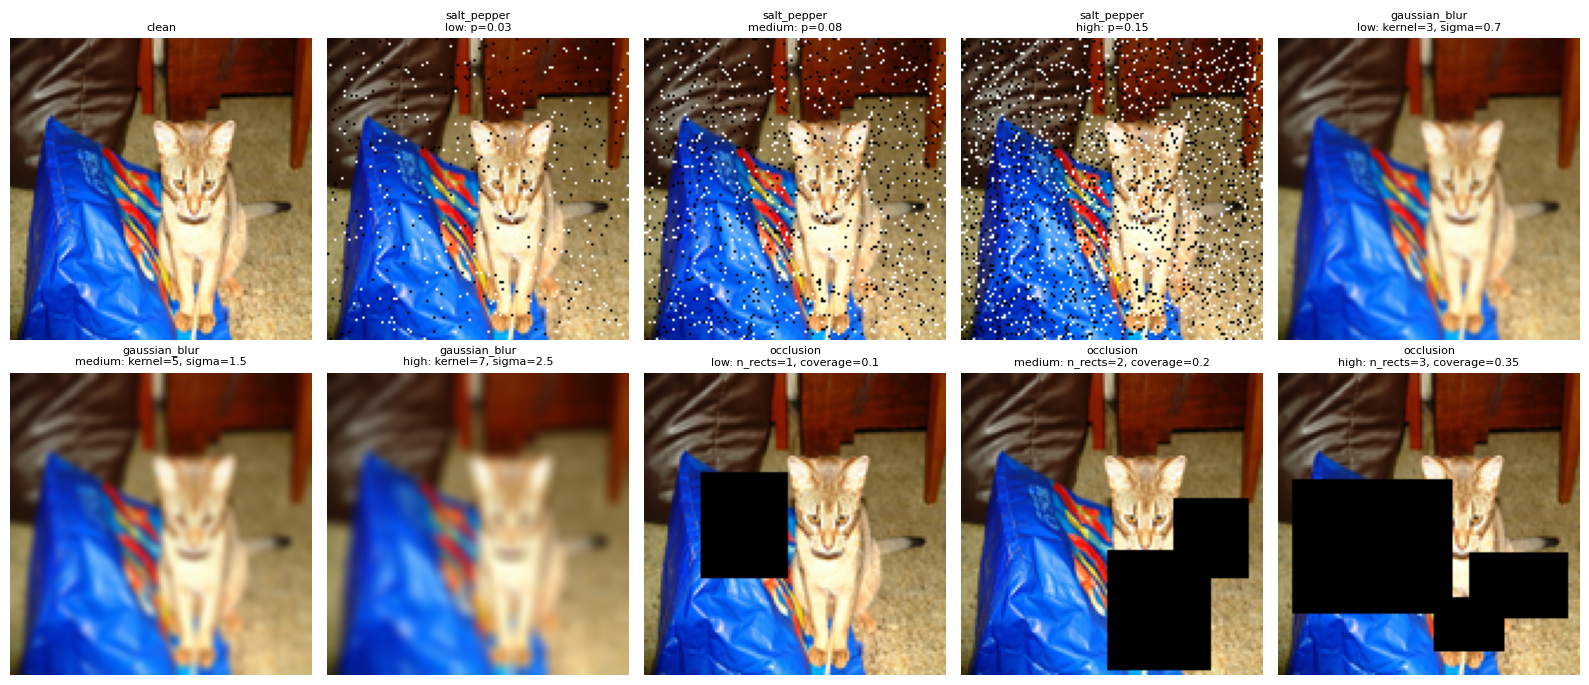

Five loads of the same training image give labels: [1, 2, 1, 1, 0]


In [13]:
# Corruption gallery: one validation image under every fixed test level
img = val_images[0].astype(np.float32) / 255.0
rng = np.random.default_rng(0)
panels = [("clean", img)]
for ctype, levels in TEST_LEVELS.items():
    for sev, cfg in levels:
        p = {"type": ctype, "seed": 123, **cfg}
        if ctype == "occlusion":
            p["rects"], _ = cc.sample_rectangles(IMG_SIZE, IMG_SIZE, cfg["n_rects"], cfg["coverage"], rng)
        label = ", ".join(f"{k}={v}" for k, v in cfg.items())
        panels.append((f"{ctype}\n{sev}: {label}", apply_corruption(img, p)))
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (t, im) in zip(axes.ravel(), panels):
    ax.imshow(im); ax.set_title(t, fontsize=8); ax.axis("off")
plt.tight_layout(); plt.savefig(f"{T1}/figures/corruption_gallery.png", dpi=150); plt.show()

# Check that training-time sampling is genuinely random per load
ds_check = RuntimeCorruptionDataset(train_images)
print("Five loads of the same training image give labels:", [ds_check[0][2] for _ in range(5)])

## 4. Weights & Biases login and Optuna study

Each Optuna trial is logged to W&B as its own run (group `task1-optuna`). The study is stored in SQLite and copied to Drive after every trial, so rerunning this cell continues the study.

The selection objective is `val_L1 + (1 - val_SSIM)` with fixed weights. It deliberately does not use the tuned `alpha`, otherwise Optuna could improve the score by changing the metric rather than the model.

In [14]:
import wandb
try:
    from google.colab import userdata
    wandb.login(key=userdata.get("WANDB_API_KEY"))
except Exception as e:
    print("Colab secret not found, falling back to interactive login:", e)
    wandb.login()

Colab secret not found, falling back to interactive login: Requesting secret WANDB_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: WARNING Invalid choice


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: emanhuda79 (emanhuda79-mm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [15]:
from torchvision.utils import make_grid

val_ds = ManifestDataset(val_images, val_entries)
val_loader = make_loader(val_ds, 128, False, NUM_WORKERS)

def build_model(cfg):
    return ConvAutoencoder(cfg["base_channels"], cfg["latent_channels"], cfg["dropout"],
                           cfg.get("skip_channels", 0)).to(device)

# Fixed validation samples (2 per condition) logged at intervals to watch the model develop
FIXED_VAL = [k for c in CONDITIONS for k in [i for i, e in enumerate(val_entries) if e["type"] == c][:2]]

@torch.no_grad()
def log_val_images(model, epoch):
    model.eval()
    xs, ys = zip(*[val_ds[k][:2] for k in FIXED_VAL])
    x, y = torch.stack(xs).to(device), torch.stack(ys).to(device)
    out = model(x)
    grid = make_grid(torch.cat([x, out, y]), nrow=len(FIXED_VAL))
    wandb.log({"val_samples": wandb.Image(grid, caption="row 1 corrupted | row 2 restored | row 3 clean"),
               "epoch": epoch})

def fit(cfg, epochs, run_name, group, ckpt_dir=None, patience=None, image_every=0):
    """Train one configuration. With ckpt_dir set it saves best.pt / last.pt and resumes from last.pt."""
    seed_everything(SEED)
    model = build_model(cfg)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=cfg["lr"] * 0.01)
    start, best, best_epoch, history, wandb_id = 0, float("inf"), -1, [], None
    last_path = best_path = None
    if ckpt_dir:
        last_path, best_path = f"{ckpt_dir}/last.pt", f"{ckpt_dir}/best.pt"
        if os.path.exists(last_path):
            ck = torch.load(last_path, map_location=device)
            model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"]); sched.load_state_dict(ck["sched"])
            start, best, best_epoch = ck["epoch"] + 1, ck["best"], ck["best_epoch"]
            history, wandb_id = ck["history"], ck["wandb_id"]
            print(f"Resuming from epoch {start}")
    run = wandb.init(project=WANDB_PROJECT, group=group, name=run_name, id=wandb_id, resume="allow",
                     config={**cfg, "epochs": epochs, "task": "task1",
                             "params": count_params(model), "latent_dim": model.latent_dim()})
    train_loader = make_loader(RuntimeCorruptionDataset(train_images), cfg["batch_size"], True, NUM_WORKERS)
    for epoch in range(start, epochs):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, opt, cfg["alpha"], device)
        va, _ = evaluate(model, val_loader, device)
        sched.step()
        rec = {"epoch": epoch, "lr": opt.param_groups[0]["lr"], "epoch_time_s": time.time() - t0,
               **{f"train/{k}": v for k, v in tr.items()}, **{f"val/{k}": v for k, v in va.items()}}
        history.append(rec)
        wandb.log(rec)
        if va["objective"] < best:
            best, best_epoch = va["objective"], epoch
            if ckpt_dir:
                torch.save({"model": model.state_dict(), "cfg": cfg, "epoch": epoch, "val": va}, best_path)
        if ckpt_dir:
            torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "sched": sched.state_dict(),
                        "epoch": epoch, "best": best, "best_epoch": best_epoch, "history": history,
                        "wandb_id": run.id}, last_path)
        if image_every and (epoch % image_every == 0 or epoch == epochs - 1):
            log_val_images(model, epoch)
        print(f"ep {epoch:3d} | train loss {tr['loss']:.4f} | val obj {va['objective']:.4f} "
              f"ssim {va['ssim']:.4f} psnr {va['psnr']:.2f} | {rec['epoch_time_s']:.0f}s")
        if patience and epoch - best_epoch >= patience:
            print(f"Early stopping at epoch {epoch} (best epoch {best_epoch})")
            break
    run.summary.update({"best_val_objective": best, "best_epoch": best_epoch})
    run.finish()
    if ckpt_dir:
        model.load_state_dict(torch.load(best_path, map_location=device)["model"])
    return model, history, best, best_epoch

In [16]:
import optuna

SEARCH_SPACE = {
    "lr":              ("float_log", 1e-4, 3e-3),
    "batch_size":      ("categorical", [16, 32, 64]),
    "base_channels":   ("categorical", [16, 32, 48]),       # encoder widths: c, 2c, 4c, 8c, 8c
    "latent_channels": ("categorical", [8, 16, 32, 64]),    # bottleneck dim = latent_channels x 8 x 8
    "dropout":         ("float", 0.0, 0.3),
    "alpha":           ("float", 0.5, 0.95),                # L1 weight in the loss
}

def suggest(trial):
    p = {}
    for name, spec in SEARCH_SPACE.items():
        if spec[0] == "float_log":
            p[name] = trial.suggest_float(name, spec[1], spec[2], log=True)
        elif spec[0] == "float":
            p[name] = trial.suggest_float(name, spec[1], spec[2])
        else:
            p[name] = trial.suggest_categorical(name, spec[1])
    return p

def objective(trial):
    seed_everything(SEED + trial.number)
    cfg = {**suggest(trial), "skip_channels": 0}
    model = build_model(cfg)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    train_loader = make_loader(RuntimeCorruptionDataset(train_images), cfg["batch_size"], True, NUM_WORKERS)
    run = wandb.init(project=WANDB_PROJECT, group="task1-optuna", name=f"trial-{trial.number:03d}",
                     config={**cfg, "trial": trial.number, "latent_dim": model.latent_dim(),
                             "params": count_params(model)})
    best = float("inf")
    try:
        for epoch in range(OPTUNA_EPOCHS):
            tr = train_one_epoch(model, train_loader, opt, cfg["alpha"], device)
            va, _ = evaluate(model, val_loader, device)
            wandb.log({"epoch": epoch, **{f"train/{k}": v for k, v in tr.items()},
                       **{f"val/{k}": v for k, v in va.items()}})
            if va["objective"] < best:
                best = va["objective"]
                trial.set_user_attr("val_ssim", va["ssim"]); trial.set_user_attr("val_psnr", va["psnr"])
                trial.set_user_attr("val_l1", va["l1"])
            trial.report(va["objective"], epoch)
            if trial.should_prune():
                run.summary["state"] = "pruned"
                raise optuna.TrialPruned()
        run.summary["state"] = "complete"
        return best
    finally:
        run.finish()
        del model, opt, train_loader
        torch.cuda.empty_cache()

LOCAL_DB, DRIVE_DB = "/content/task1_optuna.db", f"{T1}/optuna/task1_optuna.db"
if os.path.exists(DRIVE_DB) and not os.path.exists(LOCAL_DB):
    shutil.copy(DRIVE_DB, LOCAL_DB)
study = optuna.create_study(study_name="task1_universal_dae", storage=f"sqlite:///{LOCAL_DB}",
                            direction="minimize", load_if_exists=True,
                            sampler=optuna.samplers.TPESampler(seed=SEED),
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3))
finished = [t for t in study.trials if t.state in (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED)]
remaining = max(0, OPTUNA_TRIALS - len(finished))
print(f"{len(finished)} trials already finished, running {remaining} more")
study.optimize(objective, n_trials=remaining, gc_after_trial=True,
               callbacks=[lambda s, t: shutil.copy(LOCAL_DB, DRIVE_DB)])

[I 2026-10-03 17:42:53,714] Using an existing study with `study_name='task1_universal_dae'` instead of creating a new one.


11 trials already finished, running 14 more


epoch,▁▂▃▄▅▆▇█
train/l1,█▃▂▂▂▁▁▁
train/loss,█▄▃▃▂▂▁▁
train/ssim,▁▄▅▆▇▇██
val/l1,█▄▃▃▂▂▁▁
val/objective,█▅▄▄▃▂▂▁
val/psnr,▁▅▅▆▇▇██
val/psnr_clean,▁▄▅▆▇▇▇█
val/psnr_gaussian_blur,▁▄▅▅▆▇▇█
val/psnr_occlusion,▁▆▆▇▇▇██
+6,...


[I 2026-10-03 17:47:21,890] Trial 11 finished with value: 0.5147756114602089 and parameters: {'lr': 0.00011446987023999696, 'batch_size': 16, 'base_channels': 48, 'latent_channels': 64, 'dropout': 0.266952537187001, 'alpha': 0.6936773220020732}. Best is trial 11 with value: 0.5147756114602089.


epoch,▁▂▃▄▅▆▇█
train/l1,█▃▂▂▂▁▁▁
train/loss,█▄▃▃▂▂▁▁
train/ssim,▁▄▅▆▇▇██
val/l1,█▅▄▃▂▂▂▁
val/objective,█▆▄▄▂▂▂▁
val/psnr,▁▄▅▅▇▇██
val/psnr_clean,▁▄▅▅▇▇██
val/psnr_gaussian_blur,▁▄▅▅▇▇██
val/psnr_occlusion,▁▂▄▅▇▇██
+6,...


...

[I 2026-10-03 18:36:53,754] Trial 22 finished with value: 0.487077459692955 and parameters: {'lr': 0.0001715417940525604, 'batch_size': 16, 'base_channels': 48, 'latent_channels': 8, 'dropout': 0.1944759351823424, 'alpha': 0.6586778343118317}. Best is trial 18 with value: 0.456086203455925.


epoch,▁▂▃▄▅▆▇█
train/l1,█▄▃▂▂▁▂▁
train/loss,█▅▄▃▂▂▁▁
train/ssim,▁▄▅▆▇▇██
val/l1,█▄▃▃▂▂▃▁
val/objective,█▅▄▃▂▂▂▁
val/psnr,▁▄▅▆▇▇▆█
val/psnr_clean,▁▄▅▆▇▇▆█
val/psnr_gaussian_blur,▁▄▅▅▇▇▇█
val/psnr_occlusion,▁▅▄▆▇▇▅█
+6,...


[I 2026-10-03 18:41:23,399] Trial 23 finished with value: 0.46736137568950653 and parameters: {'lr': 0.0008347982096554516, 'batch_size': 16, 'base_channels': 48, 'latent_channels': 64, 'dropout': 0.22495009417998363, 'alpha': 0.5821387563203378}. Best is trial 18 with value: 0.456086203455925.


epoch,▁▃▆█
train/l1,█▃▁▁
train/loss,█▄▂▁
train/ssim,▁▅▇█
val/l1,█▂▁▁
val/objective,█▃▂▁
val/psnr,▁▇██
val/psnr_clean,▁▆▇█
val/psnr_gaussian_blur,▁▆▇█
val/psnr_occlusion,▁██▅
+6,...


[I 2026-10-03 18:43:47,612] Trial 24 pruned. 


{
  "study_name": "task1_universal_dae",
  "objective": "val_L1 + (1 - val_SSIM), minimise",
  "epochs_per_trial": 8,
  "search_space": {
    "lr": [
      "float_log",
      0.0001,
      0.003
    ],
    "batch_size": [
      "categorical",
      [
        16,
        32,
        64
      ]
    ],
    "base_channels": [
      "categorical",
      [
        16,
        32,
        48
      ]
    ],
    "latent_channels": [
      "categorical",
      [
        8,
        16,
        32,
        64
      ]
    ],
    "dropout": [
      "float",
      0.0,
      0.3
    ],
    "alpha": [
      "float",
      0.5,
      0.95
    ]
  },
  "n_trials": 25,
  "n_complete": 23,
  "n_pruned": 2,
  "best_trial": 18,
  "best_value": 0.456086203455925,
  "best_params": {
    "lr": 0.00042057241220408675,
    "batch_size": 16,
    "base_channels": 48,
    "latent_channels": 64,
    "dropout": 0.2191038368562885,
    "alpha": 0.5082890907740095
  },
  "best_user_attrs": {
    "val_l1": 0.07474558055

/tmp/ipykernel_3741/2065262166.py:20: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(12, 5); plt.tight_layout()


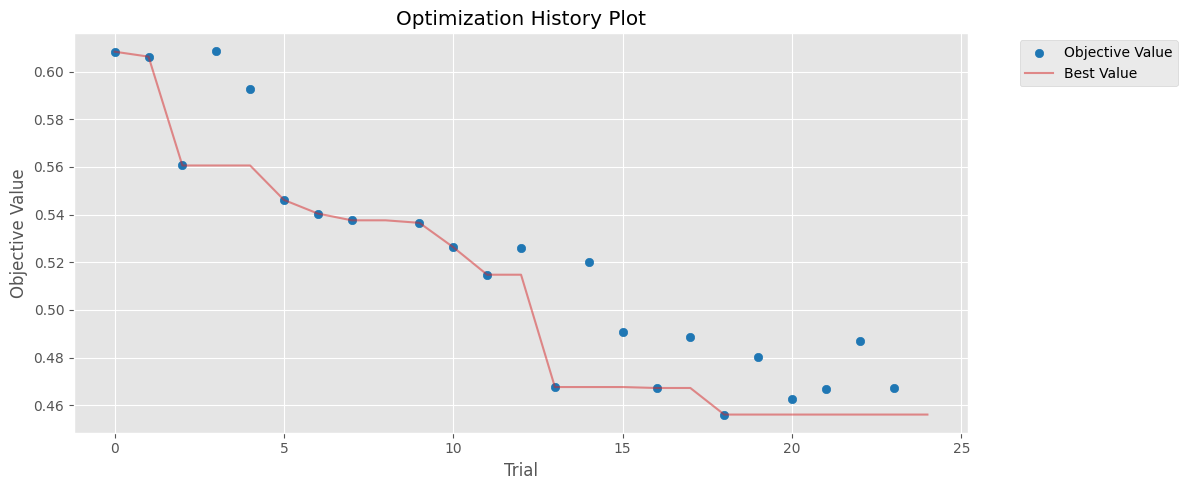

/tmp/ipykernel_3741/2065262166.py:20: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(12, 5); plt.tight_layout()


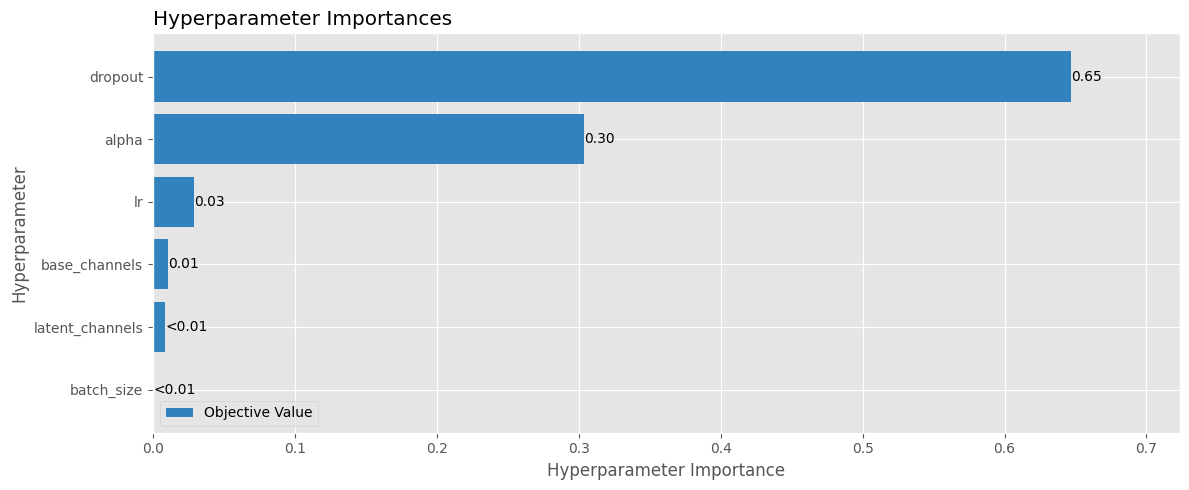

/tmp/ipykernel_3741/2065262166.py:20: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(12, 5); plt.tight_layout()


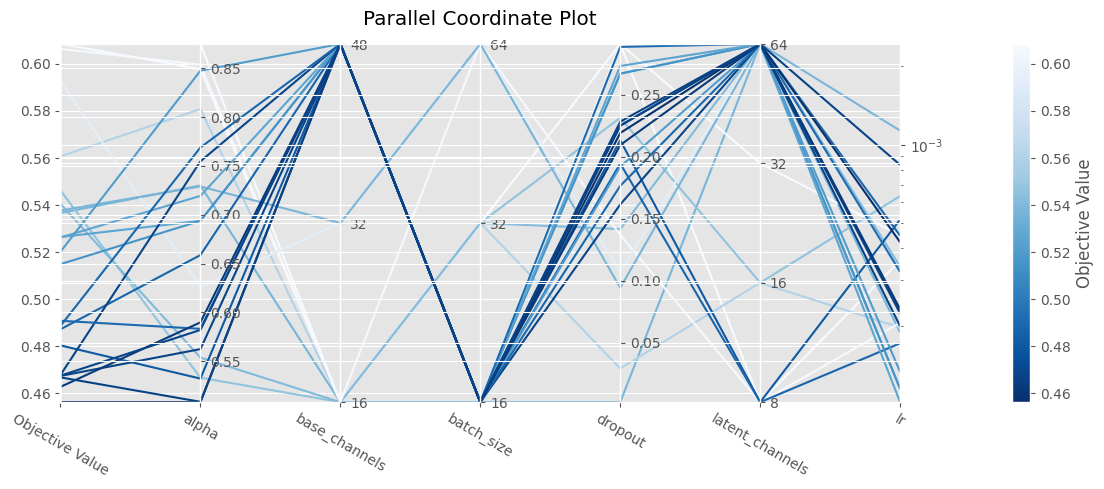

/tmp/ipykernel_3741/2065262166.py:20: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(12, 5); plt.tight_layout()
/tmp/ipykernel_3741/2065262166.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fn(study); fig = plt.gcf(); fig.set_size_inches(12, 5); plt.tight_layout()


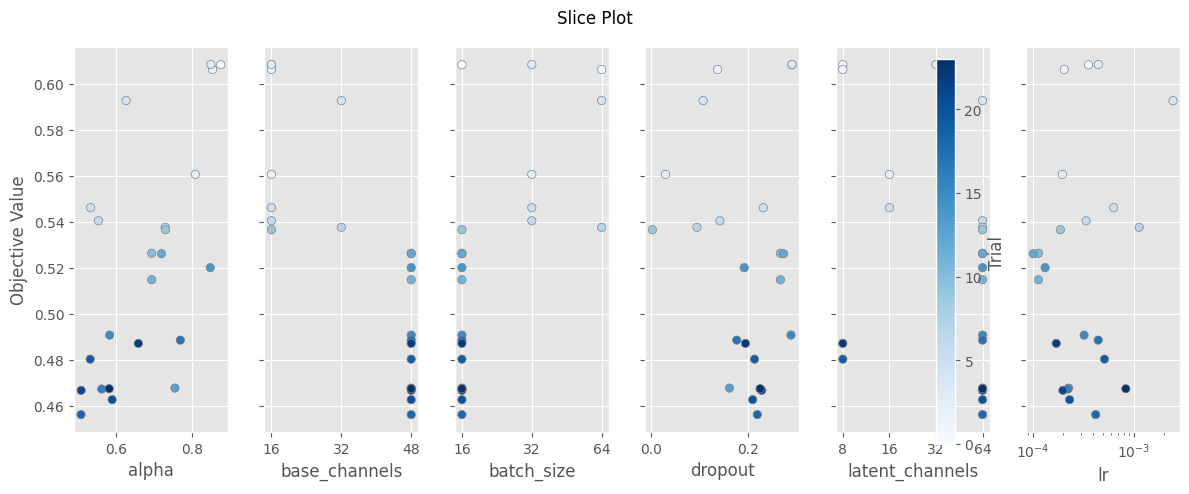

In [17]:
from optuna.trial import TrialState
from optuna.visualization import matplotlib as ovm

tdf_opt = study.trials_dataframe()
tdf_opt.to_csv(f"{T1}/optuna/task1_trials.csv", index=False)
n_complete = len([t for t in study.trials if t.state == TrialState.COMPLETE])
n_pruned = len([t for t in study.trials if t.state == TrialState.PRUNED])
best = study.best_trial
optuna_summary = {"study_name": study.study_name, "objective": "val_L1 + (1 - val_SSIM), minimise",
                  "epochs_per_trial": OPTUNA_EPOCHS, "search_space": SEARCH_SPACE,
                  "n_trials": len(study.trials), "n_complete": n_complete, "n_pruned": n_pruned,
                  "best_trial": best.number, "best_value": best.value,
                  "best_params": best.params, "best_user_attrs": best.user_attrs}
json.dump(optuna_summary, open(f"{T1}/optuna/task1_optuna_summary.json", "w"), indent=2)
print(json.dumps(optuna_summary, indent=2))

for name, fn in [("history", ovm.plot_optimization_history), ("importance", ovm.plot_param_importances),
                 ("parallel", ovm.plot_parallel_coordinate), ("slice", ovm.plot_slice)]:
    try:
        fn(study); fig = plt.gcf(); fig.set_size_inches(12, 5); plt.tight_layout()
        fig.savefig(f"{T1}/figures/optuna_{name}.png", dpi=150); plt.show()
    except Exception as e:
        print(f"Skipped {name} plot: {e}")

## 5. Skip-connection ablation

The brief allows limited skips only if their effect is investigated. This trains the best configuration twice for the same number of epochs: once with no skip, once with one narrow 16-channel skip at 16 x 16 resolution. Watch the salt-and-pepper and occlusion columns: if the skip version is better on blur but worse on those, the skip is leaking corruption into the output. Set `FINAL_SKIP_CHANNELS` in Section 6 based on this table.

In [18]:
BEST_CFG = {**study.best_params, "skip_channels": 0}
if RUN_ABLATION:
    rows = []
    for skip in (0, 16):
        cfg = {**BEST_CFG, "skip_channels": skip}
        model, hist, b, be = fit(cfg, ABLATION_EPOCHS, f"ablation-skip{skip}", "task1-skip-ablation")
        va, _ = evaluate(model, val_loader, device)
        rows.append({"skip_channels": skip, "best_epoch": be, **va})
        del model; torch.cuda.empty_cache()
    abl = pd.DataFrame(rows).set_index("skip_channels")
    abl.to_csv(f"{T1}/results/skip_ablation.csv")
    display(abl.round(4))

ep   0 | train loss 0.3784 | val obj 0.6725 ssim 0.4332 psnr 17.11 | 33s
ep   1 | train loss 0.3221 | val obj 0.6092 ssim 0.4862 psnr 18.11 | 33s
ep   2 | train loss 0.2989 | val obj 0.5666 ssim 0.5202 psnr 18.82 | 32s
ep   3 | train loss 0.2831 | val obj 0.5540 ssim 0.5336 psnr 18.93 | 33s
ep   4 | train loss 0.2712 | val obj 0.5083 ssim 0.5720 psnr 19.47 | 33s
ep   5 | train loss 0.2601 | val obj 0.4911 ssim 0.5886 psnr 19.51 | 33s
ep   6 | train loss 0.2531 | val obj 0.4848 ssim 0.5925 psnr 19.89 | 33s
ep   7 | train loss 0.2469 | val obj 0.4669 ssim 0.6098 psnr 19.85 | 33s
ep   8 | train loss 0.2403 | val obj 0.4595 ssim 0.6176 psnr 19.74 | 33s
ep   9 | train loss 0.2367 | val obj 0.4523 ssim 0.6224 psnr 20.16 | 33s
ep  10 | train loss 0.2326 | val obj 0.4383 ssim 0.6341 psnr 20.39 | 33s
ep  11 | train loss 0.2304 | val obj 0.4334 ssim 0.6390 psnr 20.30 | 33s
ep  12 | train loss 0.2267 | val obj 0.4283 ssim 0.6431 psnr 20.51 | 33s
ep  13 | train loss 0.2252 | val obj 0.4228 ssim 0.

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch_time_s,█▅▁▅▂▃▄▄▄▄▄▃▄▄▅▄▄▄▅▃
lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
train/l1,█▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train/loss,█▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
train/ssim,▁▃▄▅▅▆▆▇▇▇▇▇████████
val/l1,█▆▄▅▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
val/objective,█▆▅▅▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁
val/psnr,▁▃▄▄▅▅▆▆▆▇▇▇▇███████
val/psnr_clean,▁▂▄▄▅▅▆▆▅▆▇▇▇█▇█████
+8,...


ep   0 | train loss 0.3264 | val obj 0.5989 ssim 0.5249 psnr 16.78 | 33s
ep   1 | train loss 0.2568 | val obj 0.4627 ssim 0.6175 psnr 19.47 | 33s
ep   2 | train loss 0.2326 | val obj 0.4202 ssim 0.6536 psnr 20.15 | 33s
ep   3 | train loss 0.2178 | val obj 0.4100 ssim 0.6638 psnr 20.38 | 33s
ep   4 | train loss 0.2085 | val obj 0.3911 ssim 0.6806 psnr 20.59 | 33s
ep   5 | train loss 0.2010 | val obj 0.4025 ssim 0.6774 psnr 19.59 | 33s
ep   6 | train loss 0.1937 | val obj 0.3568 ssim 0.7106 psnr 21.02 | 33s
ep   7 | train loss 0.1876 | val obj 0.3462 ssim 0.7192 psnr 21.31 | 33s
ep   8 | train loss 0.1812 | val obj 0.3318 ssim 0.7338 psnr 21.43 | 33s
ep   9 | train loss 0.1786 | val obj 0.3199 ssim 0.7434 psnr 21.58 | 33s
ep  10 | train loss 0.1757 | val obj 0.3168 ssim 0.7466 psnr 21.61 | 33s
ep  11 | train loss 0.1719 | val obj 0.3097 ssim 0.7528 psnr 21.84 | 33s
ep  12 | train loss 0.1687 | val obj 0.3050 ssim 0.7565 psnr 21.91 | 33s
ep  13 | train loss 0.1681 | val obj 0.3007 ssim 0.

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch_time_s,█▁▄▅▃▂▆▃▃▄█▄▃▅▄▄▄█▄▅
lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
train/l1,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/ssim,▁▄▅▆▆▆▇▇▇▇▇█████████
val/l1,█▃▃▃▂▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/objective,█▅▄▄▃▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁
val/psnr,▁▄▅▆▆▅▇▇▇▇▇█████████
val/psnr_clean,▁▄▄▅▆▅▆▆▇▇▇▇▇▇▇█████
+8,...


,best_epoch,l1,psnr,ssim,objective,ssim_clean,psnr_clean,ssim_salt_pepper,psnr_salt_pepper,ssim_gaussian_blur,psnr_gaussian_blur,ssim_occlusion,psnr_occlusion
skip_channels,,,,,,,,,,,,,
0,19,0.0685,20.8598,0.6582,0.4103,0.6743,21.1134,0.6812,21.4747,0.6836,21.7456,0.5939,19.1054
16,17,0.0597,22.1674,0.7705,0.2892,0.8009,22.7491,0.7990,23.0230,0.7962,23.2248,0.6861,19.6726


## 6. Final training with the best configuration

In [19]:
FINAL_SKIP_CHANNELS = 0     # change to 16 only if the ablation clearly supports it
FINAL_CFG = {**study.best_params, "skip_channels": FINAL_SKIP_CHANNELS}
print("Final configuration:", FINAL_CFG)
final_model, history, best_obj, best_epoch = fit(FINAL_CFG, FINAL_EPOCHS, "task1-final", "task1-final",
                                                 ckpt_dir=f"{T1}/checkpoints", patience=PATIENCE, image_every=5)
hist_df = pd.DataFrame(history)
hist_df.to_csv(f"{T1}/results/final_training_history.csv", index=False)
json.dump(FINAL_CFG, open(f"{T1}/results/final_config.json", "w"), indent=2)
print(f"Best epoch {best_epoch}, best val objective {best_obj:.4f}")

Final configuration: {'lr': 0.00042057241220408675, 'batch_size': 16, 'base_channels': 48, 'latent_channels': 64, 'dropout': 0.2191038368562885, 'alpha': 0.5082890907740095, 'skip_channels': 0}


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


ep   0 | train loss 0.3768 | val obj 0.6901 ssim 0.4241 psnr 16.70 | 33s
ep   1 | train loss 0.3214 | val obj 0.5930 ssim 0.4966 psnr 18.52 | 33s
ep   2 | train loss 0.2989 | val obj 0.5862 ssim 0.5089 psnr 18.20 | 33s
ep   3 | train loss 0.2821 | val obj 0.5643 ssim 0.5301 psnr 18.33 | 33s
ep   4 | train loss 0.2705 | val obj 0.5065 ssim 0.5724 psnr 19.56 | 33s
ep   5 | train loss 0.2598 | val obj 0.4943 ssim 0.5860 psnr 19.50 | 33s
ep   6 | train loss 0.2534 | val obj 0.4979 ssim 0.5828 psnr 19.68 | 33s
ep   7 | train loss 0.2476 | val obj 0.4747 ssim 0.6036 psnr 19.69 | 33s
ep   8 | train loss 0.2415 | val obj 0.4634 ssim 0.6173 psnr 19.45 | 33s
ep   9 | train loss 0.2381 | val obj 0.4547 ssim 0.6203 psnr 20.14 | 33s
ep  10 | train loss 0.2337 | val obj 0.4470 ssim 0.6299 psnr 19.98 | 33s
ep  11 | train loss 0.2315 | val obj 0.4388 ssim 0.6354 psnr 20.22 | 33s
ep  12 | train loss 0.2282 | val obj 0.4313 ssim 0.6415 psnr 20.29 | 33s
ep  13 | train loss 0.2273 | val obj 0.4220 ssim 0.

epoch,▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████
epoch_time_s,▁▄▁▆▂▃▇▂▃▆▃▃▃▃▄▅▅▃▆▄▃▅▃▄▅▄▄▄▄█▃▄▅▄▄▄▅▅▄▄
lr,███████▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
train/l1,█▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/ssim,▁▂▃▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
val/l1,▇█▄▅▅▅▄▄▃▃▃▃▂▄▃▃▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/objective,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/psnr,▁▃▃▅▅▅▆▆▇▆▇▇▇▆▇▇▇▇▇▇▇▇██▇▇██████████████
val/psnr_clean,▁▂▁▄▄▃▅▄▅▅▅▅▆▆▆▅▆▇▇▇▆▆▇▇▇▇▇▇████████████
+8,...


Best epoch 59, best val objective 0.3513


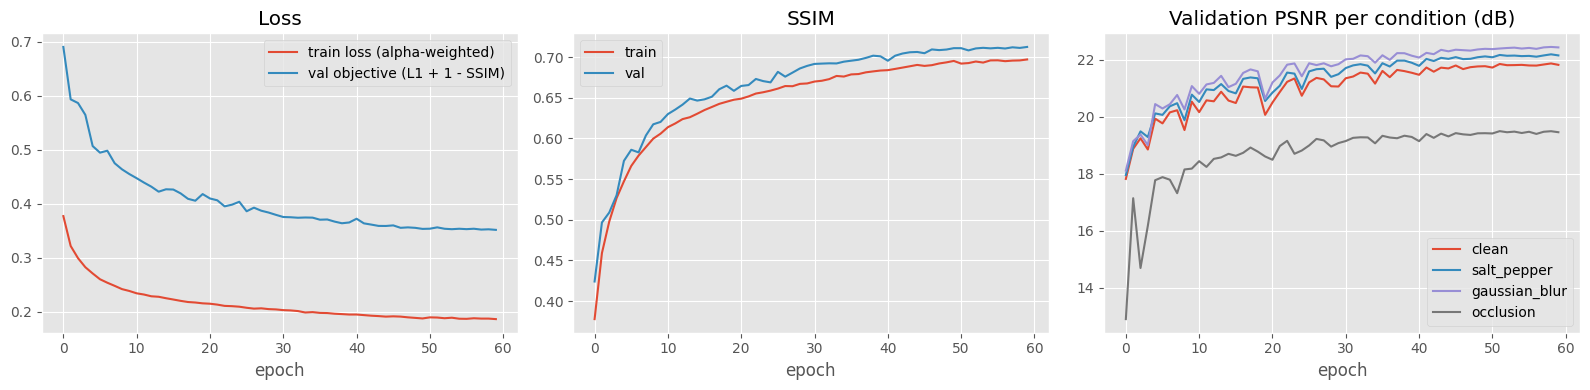

In [20]:
hist_df = pd.read_csv(f"{T1}/results/final_training_history.csv")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(hist_df.epoch, hist_df["train/loss"], label="train loss (alpha-weighted)")
ax[0].plot(hist_df.epoch, hist_df["val/objective"], label="val objective (L1 + 1 - SSIM)")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(hist_df.epoch, hist_df["train/ssim"], label="train"); ax[1].plot(hist_df.epoch, hist_df["val/ssim"], label="val")
ax[1].set_title("SSIM"); ax[1].legend()
for c in CONDITIONS:
    ax[2].plot(hist_df.epoch, hist_df[f"val/psnr_{c}"], label=c)
ax[2].set_title("Validation PSNR per condition (dB)"); ax[2].legend()
for a in ax: a.set_xlabel("epoch")
plt.tight_layout(); plt.savefig(f"{T1}/figures/training_curves.png", dpi=150); plt.show()

## 7. Final test evaluation (first and only use of the official test set)

Every test image is evaluated clean and under 3 corruptions x 3 fixed severities. The "input" columns are the no-restoration baseline, which shows how much the model actually improves each case.

In [21]:
ck = torch.load(f"{T1}/checkpoints/best.pt", map_location=device)
model = build_model(ck["cfg"]); model.load_state_dict(ck["model"]); model.eval()
test_ds = ManifestDataset(test_images, test_entries)
test_loader = make_loader(test_ds, 128, False, NUM_WORKERS)
summary, per = evaluate(model, test_loader, device, return_per_sample=True)

res = pd.DataFrame({"index": per["index"],
                    "img_idx": [test_entries[k]["img_idx"] for k in per["index"]],
                    "type": [test_entries[k]["type"] for k in per["index"]],
                    "severity": [test_entries[k]["severity"] for k in per["index"]],
                    **{m: per[m] for m in ["l1", "psnr", "ssim", "in_l1", "in_psnr", "in_ssim"]}})
res["ssim_gain"] = res.ssim - res.in_ssim
res["psnr_gain"] = res.psnr - res.in_psnr
res.to_csv(f"{T1}/results/test_per_sample.csv", index=False)

cols = ["psnr", "ssim", "l1", "in_psnr", "in_ssim", "ssim_gain"]
by_type = res.groupby("type")[cols].mean().reindex(CONDITIONS)
by_sev = (res[res.type != "clean"].groupby(["type", "severity"])[cols].mean()
          .reindex(pd.MultiIndex.from_product([CONDITIONS[1:], SEVERITIES])))
for name, t in [("test_by_condition", by_type), ("test_by_condition_severity", by_sev)]:
    t.to_csv(f"{T1}/results/{name}.csv")
    t.round(4).to_latex(f"{T1}/results/{name}.tex", float_format="%.4f")
print("Overall:", {k: round(v, 4) for k, v in summary.items()})
print("Note: input PSNR for clean images is capped at 100 dB because input equals target.")
display(by_type.round(4)); display(by_sev.round(4))
print("Share of samples where restoration made SSIM worse than the input:")
display(res.assign(worse=res.ssim_gain < 0).groupby("type")["worse"].mean().reindex(CONDITIONS).round(3))

Overall: {'l1': 0.0664, 'psnr': 21.1437, 'ssim': 0.7041, 'objective': 0.3623, 'ssim_clean': 0.7353, 'psnr_clean': 21.7541, 'ssim_salt_pepper': 0.7314, 'psnr_salt_pepper': 21.7932, 'ssim_gaussian_blur': 0.7167, 'psnr_gaussian_blur': 21.8004, 'ssim_occlusion': 0.6538, 'psnr_occlusion': 19.6339}
Note: input PSNR for clean images is capped at 100 dB because input equals target.


,psnr,ssim,l1,in_psnr,in_ssim,ssim_gain
type,,,,,,
clean,21.754101,0.7353,0.0627,100.0000,1.0000,-0.2647
salt_pepper,21.793200,0.7314,0.0627,16.3841,0.3821,0.3493
gaussian_blur,21.800400,0.7167,0.0627,27.8209,0.8136,-0.0970
occlusion,19.633900,0.6538,0.0751,13.6414,0.7127,-0.0589


psnr    ssim      l1    in_psnr  in_ssim  ssim_gain
salt_pepper   low     21.793600  0.7345  0.0626  20.133600   0.6025     0.1320
              medium  21.811800  0.7323  0.0626  15.875200   0.3396     0.3927
              high    21.774401  0.7274  0.0628  13.143700   0.2041     0.5232
gaussian_blur low     21.863001  0.7349  0.0621  32.335899   0.9436    -0.2086
              medium  21.911400  0.7254  0.0620  26.773500   0.8057    -0.0803
              high    21.626699  0.6897  0.0640  24.353201   0.6916    -0.0020
occlusion     low     20.669399  0.6984  0.0680  16.734501   0.8618    -0.1634
              medium  19.724600  0.6607  0.0737  13.357000   0.7305    -0.0698
              high    18.507799  0.6022  0.0835  10.832700   0.5457     0.0565

Share of samples where restoration made SSIM worse than the input:


,worse
type,
clean,1.000
salt_pepper,0.071
gaussian_blur,0.800
occlusion,0.666


## 8. Visual results: 12 representative examples and 4 failure cases

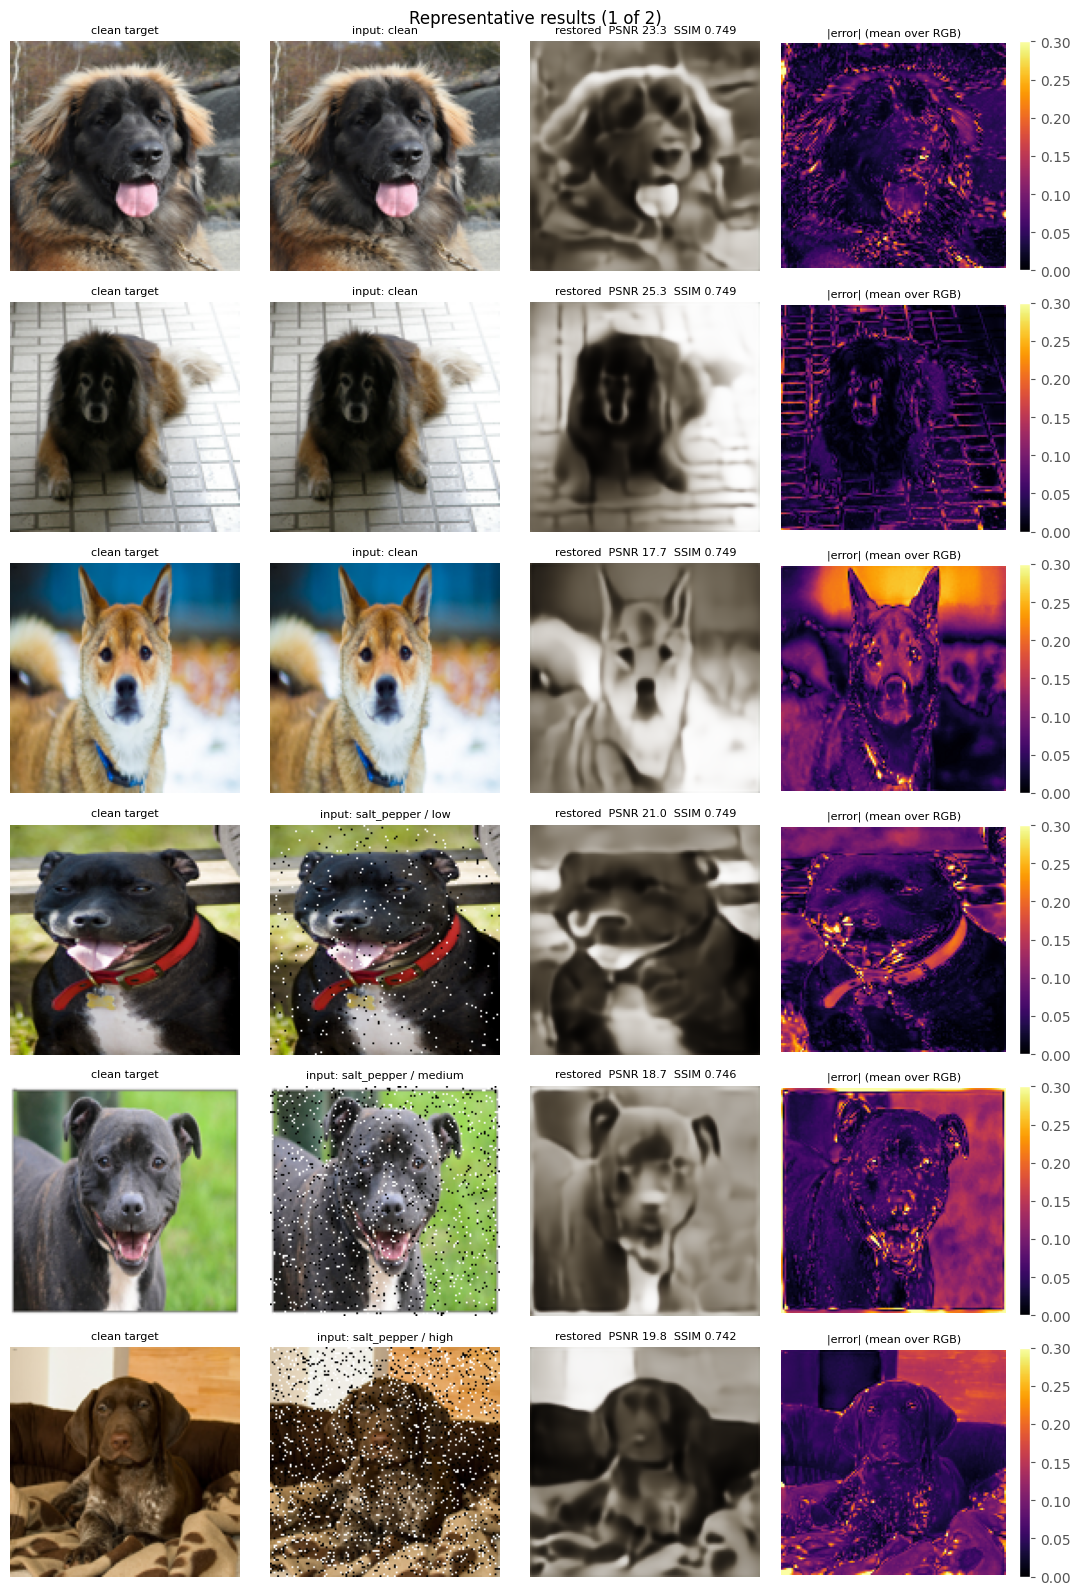

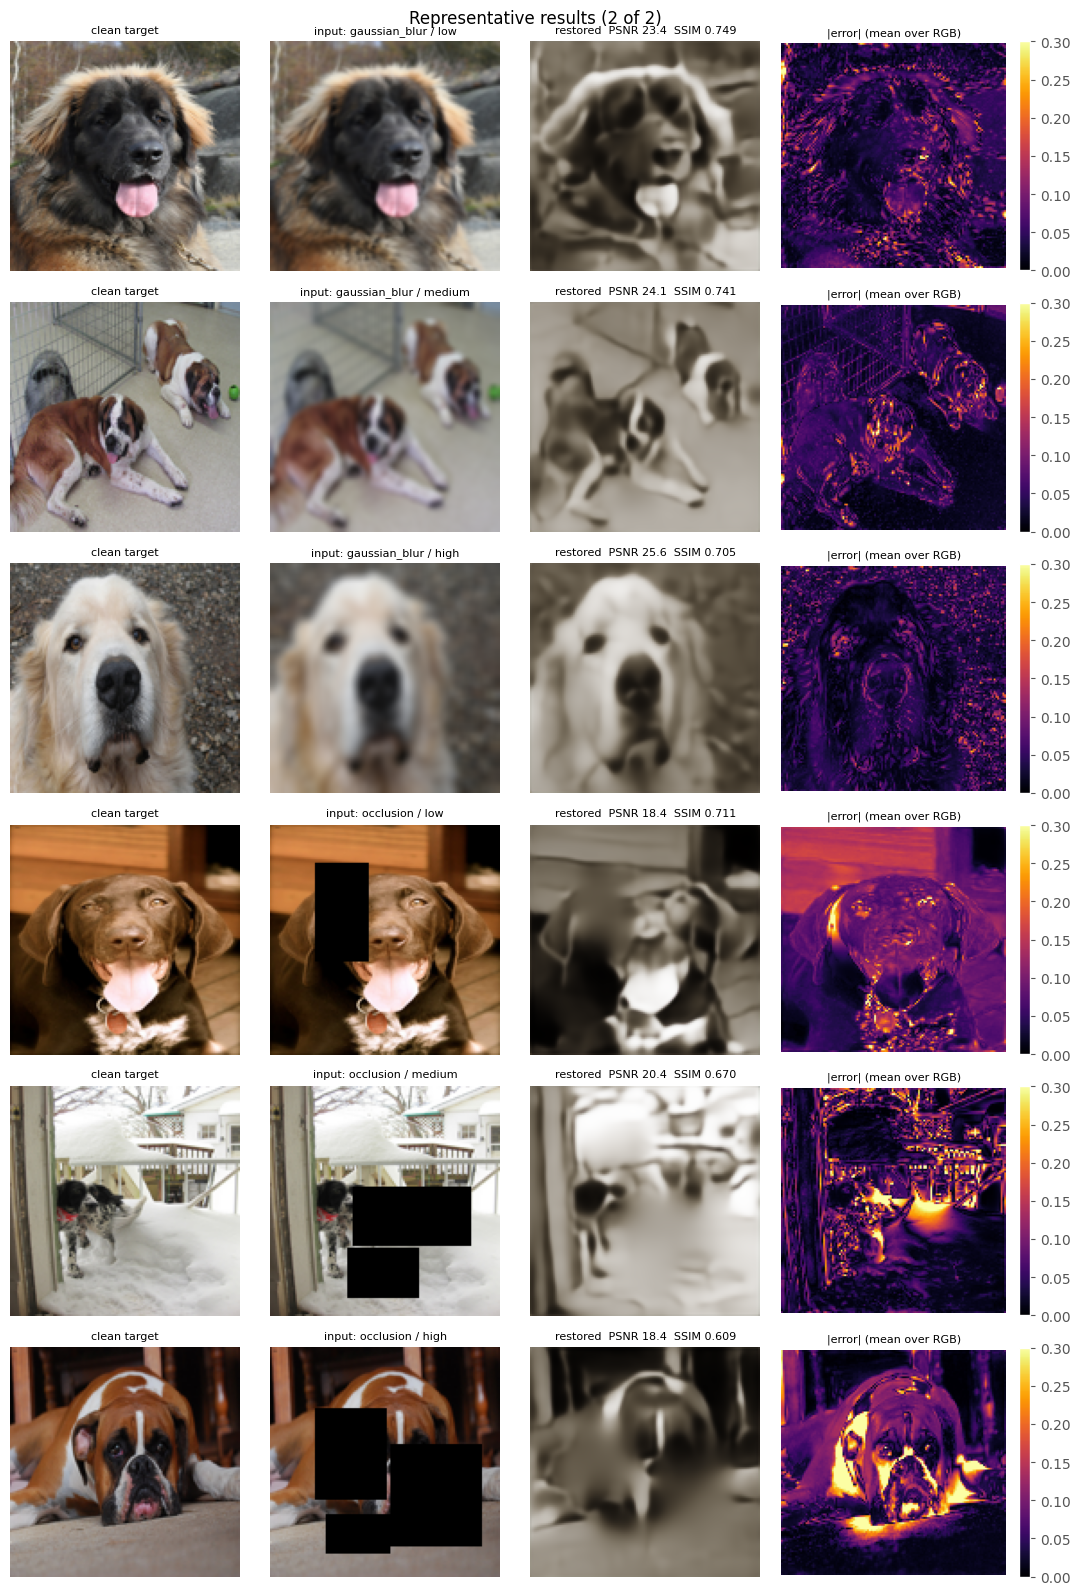

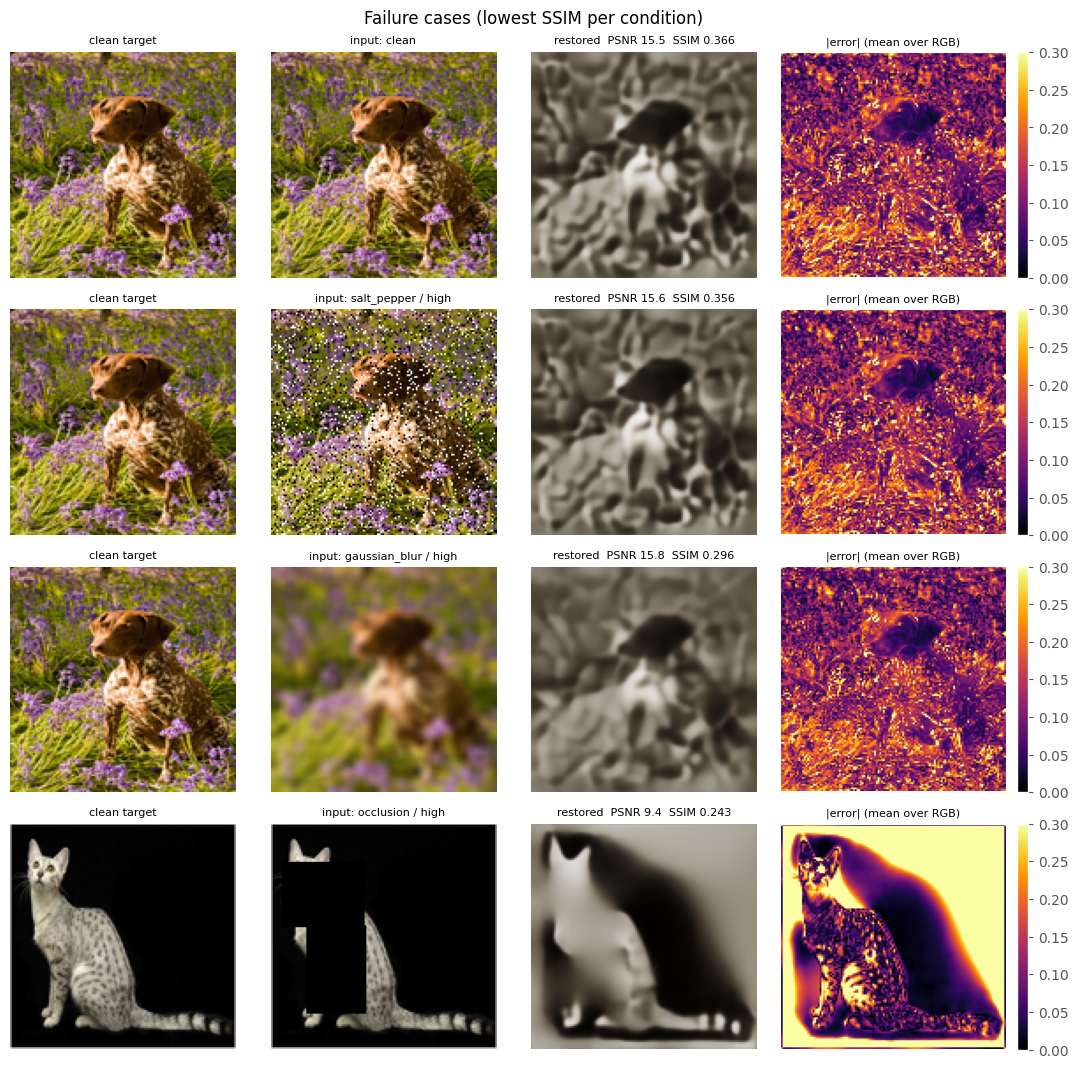

,type,severity,psnr,ssim,in_ssim,ssim_gain
index,,,,,,
14520,clean,none,15.491572,0.365966,1.000000,-0.634034
14523,salt_pepper,high,15.590162,0.355628,0.418047,-0.062419
14526,gaussian_blur,high,15.799833,0.296368,0.334816,-0.038448
11439,occlusion,high,9.395612,0.242940,0.741846,-0.498906


{'img_idx': 1452, 'type': 'clean', 'severity': 'none', 'seed': 991227922} | image: german_shorthaired_73
{'img_idx': 1452, 'type': 'salt_pepper', 'severity': 'high', 'seed': 1216515321, 'p': 0.15} | image: german_shorthaired_73
{'img_idx': 1452, 'type': 'gaussian_blur', 'severity': 'high', 'seed': 1556831404, 'kernel': 7, 'sigma': 2.5} | image: german_shorthaired_73
{'img_idx': 1143, 'type': 'occlusion', 'severity': 'high', 'seed': 1822826701, 'n_rects': 3, 'coverage': 0.3485107421875, 'target_coverage': 0.35} | image: Egyptian_Mau_60


In [22]:
@torch.no_grad()
def plot_rows(keys, title, path):
    fig, axes = plt.subplots(len(keys), 4, figsize=(11, 2.7 * len(keys)))
    for r, k in enumerate(keys):
        x, y, _, _ = test_ds[k]
        out = model(x[None].to(device))[0].cpu()
        err = (out - y).abs().mean(0).numpy()
        e, row = test_entries[k], res.set_index("index").loc[k]
        sev = "" if e["type"] == "clean" else f" / {e['severity']}"
        imgs = [(y, "clean target"), (x, f"input: {e['type']}{sev}"),
                (out, f"restored  PSNR {row.psnr:.1f}  SSIM {row.ssim:.3f}")]
        for c, (im, t) in enumerate(imgs):
            axes[r, c].imshow(im.permute(1, 2, 0).numpy()); axes[r, c].set_title(t, fontsize=8)
        h = axes[r, 3].imshow(err, cmap="inferno", vmin=0, vmax=0.3); axes[r, 3].set_title("|error| (mean over RGB)", fontsize=8)
        fig.colorbar(h, ax=axes[r, 3], fraction=0.046)
        for a in axes[r]: a.axis("off")
    fig.suptitle(title); plt.tight_layout(); fig.savefig(path, dpi=130); plt.show()

# Representative = sample closest to the group median SSIM (not cherry-picked best cases)
def near_median(g, n=1):
    return g.loc[(g.ssim - g.ssim.median()).abs().sort_values().index[:n], "index"].tolist()

rep = near_median(res[res.type == "clean"], 3)
for c in CONDITIONS[1:]:
    for s in SEVERITIES:
        rep += near_median(res[(res.type == c) & (res.severity == s)], 1)
plot_rows(rep[:6], "Representative results (1 of 2)", f"{T1}/figures/representative_1.png")
plot_rows(rep[6:], "Representative results (2 of 2)", f"{T1}/figures/representative_2.png")

# Failure cases = lowest restored SSIM for each condition
fail = [res.loc[res[res.type == c].ssim.idxmin(), "index"] for c in CONDITIONS]
plot_rows(fail, "Failure cases (lowest SSIM per condition)", f"{T1}/figures/failure_cases.png")
display(res.set_index("index").loc[fail, ["type", "severity", "psnr", "ssim", "in_ssim", "ssim_gain"]])
for k in fail:
    print({kk: vv for kk, vv in test_entries[k].items() if kk != "rects"}, "| image:", test_names[test_entries[k]["img_idx"]])

## 9. ONNX export, consistency check and tracking artefacts

The backend loads `task1_universal_dae.onnx`. Input is `float32 [N, 3, 128, 128]`, RGB, values in [0, 1]; output has the same shape.

In [23]:
import onnx, onnxruntime as ort

onnx_path = f"{T1}/onnx/task1_universal_dae.onnx"
cpu_model = build_model(ck["cfg"]).cpu(); cpu_model.load_state_dict(ck["model"]); cpu_model.eval()
dummy = torch.rand(1, 3, IMG_SIZE, IMG_SIZE)
export_kwargs = dict(input_names=["input"], output_names=["output"],
                     dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}}, opset_version=17)
try:
    torch.onnx.export(cpu_model, dummy, onnx_path, dynamo=False, **export_kwargs)
except TypeError:            # older torch without the dynamo argument
    torch.onnx.export(cpu_model, dummy, onnx_path, **export_kwargs)
onnx.checker.check_model(onnx.load(onnx_path))

# Consistency on real test inputs covering every condition and severity
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
check_keys = res.groupby(["type", "severity"]).head(8)["index"].tolist()
xb = torch.stack([test_ds[k][0] for k in check_keys])
with torch.no_grad():
    pt_out = cpu_model(xb).numpy()
ort_out = sess.run(None, {"input": xb.numpy()})[0]
diff = np.abs(pt_out - ort_out)
np.testing.assert_allclose(pt_out, ort_out, rtol=1e-3, atol=1e-4)
print(f"ONNX vs PyTorch on {len(check_keys)} test images: max abs diff {diff.max():.2e}, mean {diff.mean():.2e}  PASSED")

def latency_ms(fn, n=100):
    for _ in range(10): fn()
    t = time.perf_counter()
    for _ in range(n): fn()
    return (time.perf_counter() - t) / n * 1000

one = xb[:1]
lat_ort = latency_ms(lambda: sess.run(None, {"input": one.numpy()}))
with torch.no_grad():
    lat_pt = latency_ms(lambda: cpu_model(one))
print(f"Single-image CPU latency: ONNX Runtime {lat_ort:.1f} ms | PyTorch {lat_pt:.1f} ms")

metadata = {"task": "task1_universal_restoration", "onnx_file": os.path.basename(onnx_path),
            "input": {"name": "input", "shape": [None, 3, IMG_SIZE, IMG_SIZE], "dtype": "float32",
                      "range": [0, 1], "channel_order": "RGB", "layout": "NCHW"},
            "output": {"name": "output", "shape": [None, 3, IMG_SIZE, IMG_SIZE], "range": [0, 1]},
            "config": ck["cfg"], "best_epoch": ck["epoch"], "latent_dim": cpu_model.latent_dim(),
            "params": count_params(cpu_model),
            "onnx_check": {"n_images": len(check_keys), "max_abs_diff": float(diff.max()),
                           "mean_abs_diff": float(diff.mean())},
            "cpu_latency_ms": {"onnxruntime": lat_ort, "pytorch": lat_pt},
            "test_overall": summary}
json.dump(metadata, open(f"{T1}/onnx/task1_metadata.json", "w"), indent=2)

/tmp/ipykernel_3741/415057401.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(cpu_model, dummy, onnx_path, dynamo=False, **export_kwargs)


ONNX vs PyTorch on 80 test images: max abs diff 7.15e-07, mean 3.36e-08  PASSED
Single-image CPU latency: ONNX Runtime 110.8 ms | PyTorch 140.3 ms


In [24]:
run = wandb.init(project=WANDB_PROJECT, group="task1-final", name="task1-test-and-export", job_type="evaluation")
run.log({"test/by_condition": wandb.Table(dataframe=by_type.reset_index()),
         "test/by_condition_severity": wandb.Table(dataframe=by_sev.reset_index()),
         **{f"figures/{os.path.splitext(f)[0]}": wandb.Image(f"{T1}/figures/{f}")
            for f in sorted(os.listdir(f"{T1}/figures")) if f.endswith(".png")}})
run.summary.update({f"test/{k}": v for k, v in summary.items()})
run.summary.update({"onnx/max_abs_diff": float(diff.max()), "onnx/cpu_latency_ms": lat_ort})
art = wandb.Artifact("task1-universal-dae", type="model", metadata=metadata)
for f in [f"{T1}/checkpoints/best.pt", onnx_path, f"{T1}/onnx/task1_metadata.json"]:
    art.add_file(f)
run.log_artifact(art)
run.finish()
print("Logged results, figures, checkpoint and ONNX model to W&B")

onnx/cpu_latency_ms,110.79344
onnx/max_abs_diff,0.0
test/l1,0.0664
test/objective,0.36234
test/psnr,21.14367
test/psnr_clean,21.75406
test/psnr_gaussian_blur,21.80036
test/psnr_occlusion,19.63394
test/psnr_salt_pepper,21.79325
test/ssim,0.70407
+4,...


Logged results, figures, checkpoint and ONNX model to W&B


## Done: what Task 1 produced (all under `MyDrive/genai-assignment1/`)

- `common/*.py`: shared code, goes into the repo
- `data/split_seed42.json`, `manifests/val_manifest.json`, `manifests/test_manifest.json`: reused by Tasks 2 and 3, commit to repo (the npz cache does not go to GitHub)
- `task1/optuna/`: study database, trials CSV, summary JSON (commit to repo)
- `task1/results/`: test tables as CSV and LaTeX, ablation table, training history
- `task1/figures/`: corruption gallery, Optuna plots, training curves, representative and failure grids
- `task1/checkpoints/best.pt` and `task1/onnx/`: model files (Git LFS or a download link, not plain GitHub)